### Домашнее задание

#### Задача

Обучить любые две модели из списка, используя реальные данные, применить метод Монте-Карло для улучшения стабильности предсказаний и провести анализ качества результатов.

#### Список моделей

- Gradient Boosting
- XGBoost
- CatBoost
- Ridge Regression
- Lasso Regression
- ElasticNet

#### Инструкция

##### Подготовка данных

- Использовать данные из любой доступной базы (например, yfinance, datasets или аналоги).
- Обеспечить разделение данных на тренировочную и тестовую выборки.
- Нормализовать данные, если это необходимо для выбранных моделей.

##### Обучение моделей

- Обучить две модели из списка.
- Подобрать оптимальные параметры.

##### Применить методы Монте-Карло

- Провести симуляцию с методом Монте-Карло для обеих моделей:
    - Выполнить n симуляций (например, не меньше 30), обучая модель на случайных подвыборках тренировочных данных (bootstrap sampling).
    - Рассчитать среднее и стандартное отклонение предсказаний для тестовых данных.
- Построить доверительные интервалы для предсказаний.

##### Оценка моделей

- Вычислить метрики качества:
    - Среднеквадратическая ошибка (MSE).
    - Коэффициент детерминации (R²).
- Сравнить результаты метрик между моделями (без Монте-Карло и ним).

##### Визуализация результатов

- Построить график, показывающий:
    - Истинные значения.
    - Предсказанные значения для каждой модели.
- Добавить подписи, легенду и заголовок.

##### Вывод

Написать вывод о том, какая модель лучше справилась с задачей и почему (ориентироваться на метрики и визуализацию).

In [2]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.8/289.8 MB 1.4 MB/s eta 0:00:00


In [18]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.utils import resample
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

In [19]:
X.head(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.02381,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.97188,2401.0,2.109842,37.86,-122.22


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
param_grid = {
    'alpha': np.logspace(-3, 0, 10),
    'l1_ratio': np.linspace(0.1, 1.0, 10)
}

elastic_net = ElasticNet(random_state=42)

grid_search_en = GridSearchCV(
    estimator=elastic_net,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search_en.fit(X_train_scaled, y_train)
best_elastic_net_model = grid_search_en.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits


In [22]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_model = XGBRegressor(random_state=42)

grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

grid_search_xgb.fit(X_train_scaled, y_train)
best_xgb_model = grid_search_xgb.best_estimator_

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


Без Монте-Карло:

In [23]:
preds_en_no_mc = best_elastic_net_model.predict(X_test_scaled)
preds_xgb_no_mc = best_xgb_model.predict(X_test_scaled)
r2_score_en = best_elastic_net_model.score(X_test_scaled, y_test)
r2_score_xgb = best_xgb_model.score(X_test_scaled, y_test)
mse_en = np.mean((preds_en_no_mc - y_test) ** 2)
mse_xgb = np.mean((preds_xgb_no_mc - y_test) ** 2)

С Монте-Карло:

In [24]:
iterations = 50
xgb_pred = []
en_pred = []
for _ in range(iterations):
      X_resample, y_resample = resample(X_train_scaled, y_train, random_state=_)
      best_elastic_net_model.fit(X_resample, y_resample)
      best_xgb_model.fit(X_resample, y_resample)
      xgb_pred.append(best_xgb_model.predict(X_test_scaled))
      en_pred.append(best_elastic_net_model.predict(X_test_scaled))

r2_score_en_mc = r2_score(y_test, np.mean(en_pred, axis=0))
r2_score_xgb_mc = r2_score(y_test, np.mean(xgb_pred, axis=0))
mse_en_mc = np.mean((np.mean(en_pred, axis=0) - y_test) **2)
mse_xgb_mc = np.mean((np.mean(xgb_pred, axis=0) - y_test) ** 2)

In [25]:
data = {
    "Model": ["Elastic Net", "XGBoost", "Elastic Net (MC)", "XGBoost (MC)"],
    "R2 Score": [
        r2_score_en,
        r2_score_xgb,
        r2_score_en_mc,
        r2_score_xgb_mc
    ],
    "MSE": [
        mse_en,
        mse_xgb,
        mse_en_mc,
        mse_xgb_mc
    ]
}

df_results = pd.DataFrame(data)
print(df_results)

              Model  R2 Score       MSE
0       Elastic Net  0.576856  0.554491
1           XGBoost  0.850518  0.195883
2  Elastic Net (MC)  0.576786  0.554584
3      XGBoost (MC)  0.853520  0.191949


Для ElasticNet изменения крошечные, для XGBOOST есть прирост в 3 знаке

In [26]:
en_pred_mean = np.mean(en_pred, axis=0)
en_pred_std = np.std(en_pred, axis=0)
xgb_pred_mean = np.mean(xgb_pred, axis=0)
xgb_pred_std = np.std(xgb_pred, axis=0)

en_ci_lower = en_pred_mean - 1.96 * en_pred_std
en_ci_upper = en_pred_mean + 1.96 * en_pred_std
xgb_ci_lower = xgb_pred_mean - 1.96 * xgb_pred_std
xgb_ci_upper = xgb_pred_mean + 1.96 * xgb_pred_std

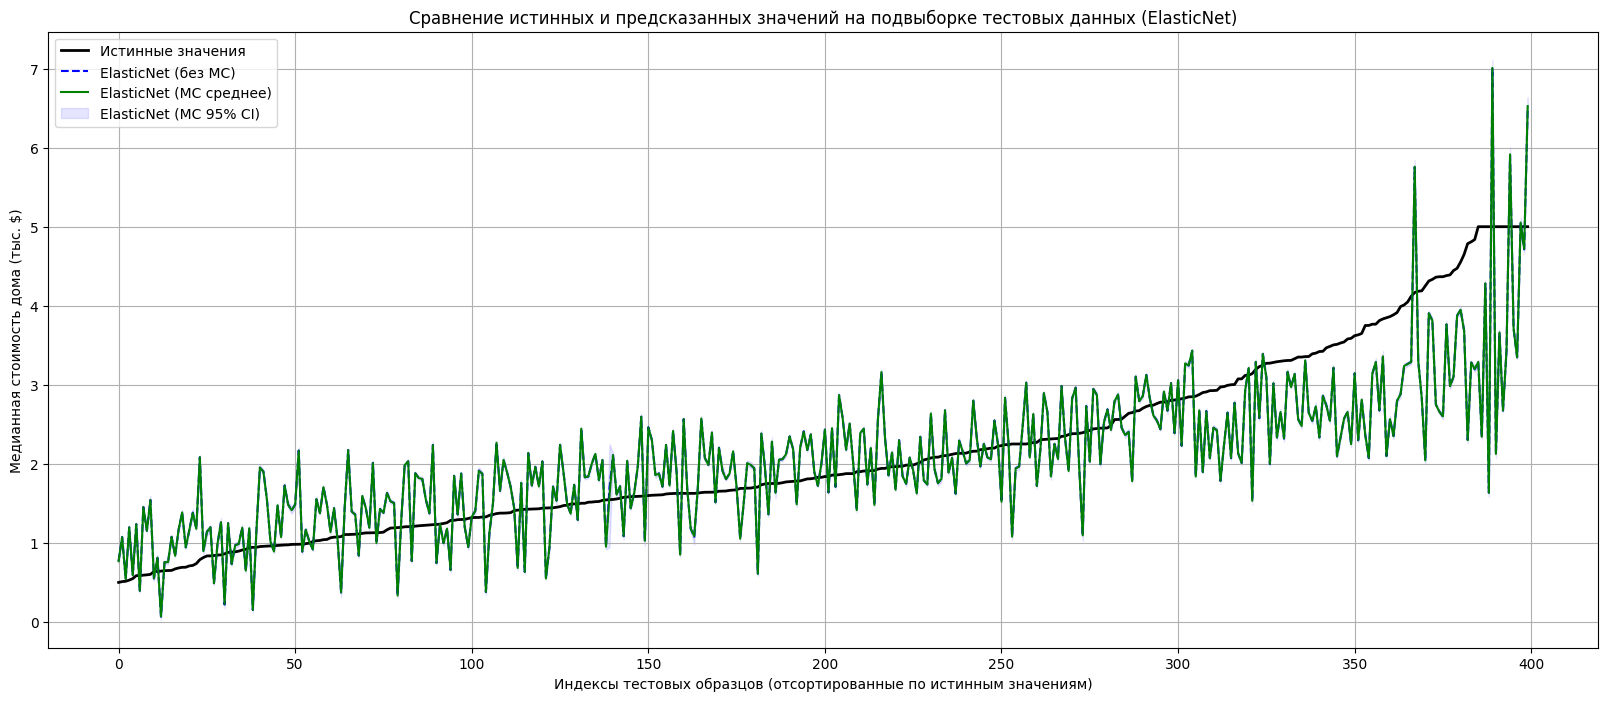

In [37]:
plt.figure(figsize=(20, 8))

np.random.seed(42)
sample_size = 400
sampled_indices = np.random.choice(len(y_test), size=sample_size, replace=False)

sorted_sample_indices = sampled_indices[np.argsort(y_test.iloc[sampled_indices])]
y_test_sampled_sorted = y_test.iloc[sorted_sample_indices]
preds_en_no_mc_sampled_sorted = preds_en_no_mc[sorted_sample_indices]
preds_xgb_no_mc_sampled_sorted = preds_xgb_no_mc[sorted_sample_indices]
en_pred_mean_sampled_sorted = en_pred_mean[sorted_sample_indices]
en_ci_lower_sampled_sorted = en_ci_lower[sorted_sample_indices]
en_ci_upper_sampled_sorted = en_ci_upper[sorted_sample_indices]
xgb_pred_mean_sampled_sorted = xgb_pred_mean[sorted_sample_indices]
xgb_ci_lower_sampled_sorted = xgb_ci_lower[sorted_sample_indices]
xgb_ci_upper_sampled_sorted = xgb_ci_upper[sorted_sample_indices]


plt.plot(y_test_sampled_sorted.values, label='Истинные значения', color='black', linewidth=2)
plt.plot(preds_en_no_mc_sampled_sorted, label='ElasticNet (без MC)', color='blue', linestyle='--')
plt.plot(en_pred_mean_sampled_sorted, label='ElasticNet (MC среднее)', color='green', linewidth=1.5)
plt.fill_between(range(len(y_test_sampled_sorted)), en_ci_lower_sampled_sorted, en_ci_upper_sampled_sorted, color='blue', alpha=0.1, label='ElasticNet (MC 95% CI)')

plt.title('Сравнение истинных и предсказанных значений на подвыборке тестовых данных (ElasticNet)')
plt.xlabel('Индексы тестовых образцов (отсортированные по истинным значениям)')
plt.ylabel('Медианная стоимость дома (тыс. $)')
plt.legend()
plt.grid(True)
plt.show()

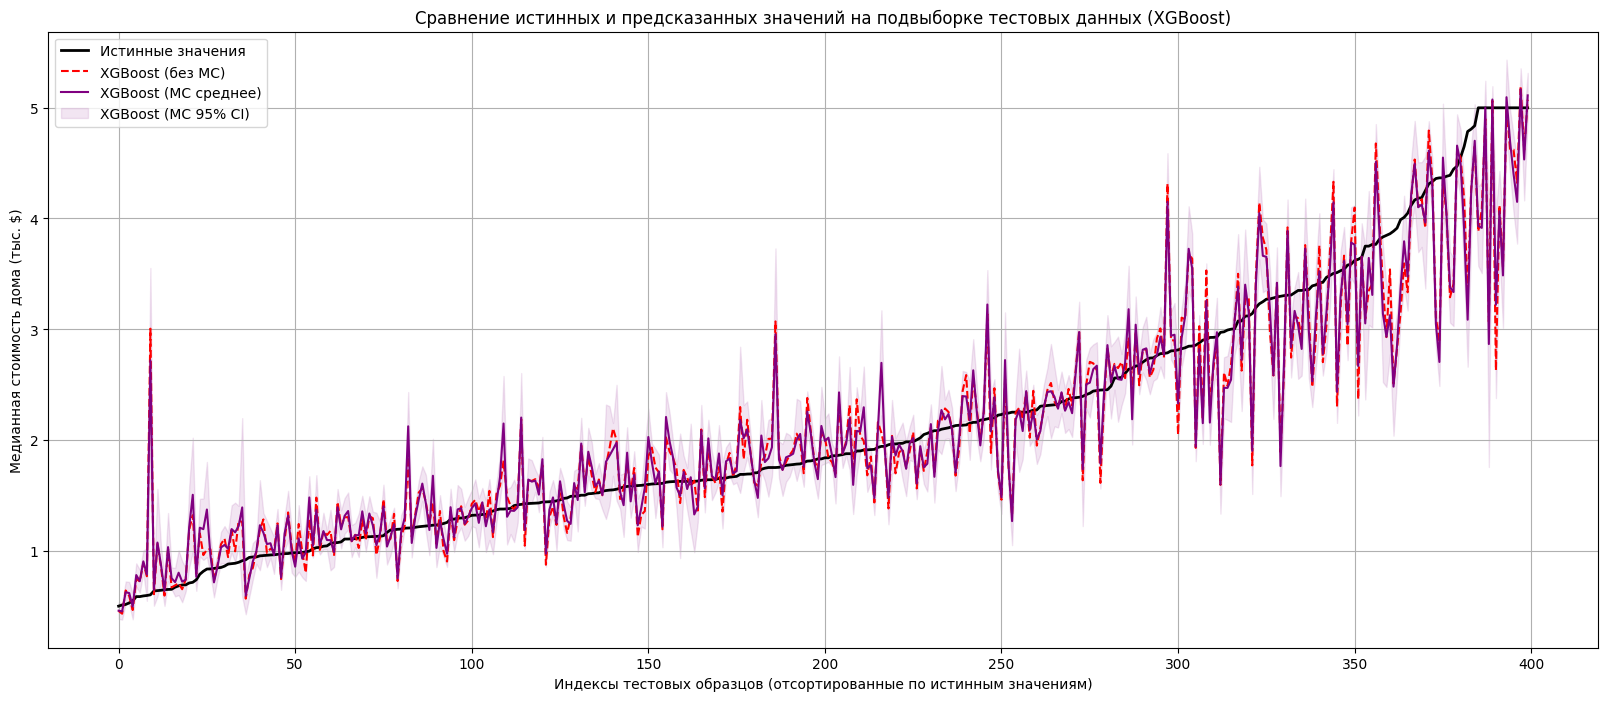

In [38]:
plt.figure(figsize=(20, 8))
plt.plot(y_test_sampled_sorted.values, label='Истинные значения', color='black', linewidth=2)
plt.plot(preds_xgb_no_mc_sampled_sorted, label='XGBoost (без MC)', color='red', linestyle='--')
plt.plot(xgb_pred_mean_sampled_sorted, label='XGBoost (MC среднее)', color='purple', linewidth=1.5)
plt.fill_between(range(len(y_test_sampled_sorted)), xgb_ci_lower_sampled_sorted, xgb_ci_upper_sampled_sorted, color='purple', alpha=0.1, label='XGBoost (MC 95% CI)')

plt.title('Сравнение истинных и предсказанных значений на подвыборке тестовых данных (XGBoost)')
plt.xlabel('Индексы тестовых образцов (отсортированные по истинным значениям)')
plt.ylabel('Медианная стоимость дома (тыс. $)')
plt.legend()
plt.grid(True)
plt.show()

Выводы:
1. ElasticNet решает задачу не лучшим образом и Монте Карло ей в этом не помогает - модель простая и стабильная с около нулевым разбросом по своей природе, ей трудно ловить зависимости сложнее линейных.
2. XGBoost выиграл по метрикам, но оказался довольно хрупкой моделью - по графику видно, что модель колеблется даже при бустрепе исходной выборке. Но усреднение помогло решить проблему и стабилизировать предсказания

ИТОГ:
Мы получили модель, хорошую по метрикам, и что немало важно - построили интервалы, которые, по графику, часто пересекают исходные значения.